## Discrete Control Comparison: DQN vs PPO on CartPole-v1

This notebook imports the camera-ready algorithm modules from `cam_ready/` and compares DQN against PPO under the same approximate environment-step budget. It also calculates computational-complexity estimates and runs per-algorithm ablations.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "cam_ready":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cam_ready.utils.complexity import discrete_cartpole_complexity
from cam_ready.utils.experiments import (
    run_discrete_cartpole_comparison,
    run_dqn_cartpole_ablations,
    run_ppo_cartpole_ablations,
    summarize_final_scores,
)
from cam_ready.utils.common import plot_comparison


def as_table(rows):
    try:
        import pandas as pd
        return pd.DataFrame(rows)
    except ImportError:
        return rows


def print_score_table(results, window):
    rows = summarize_final_scores(results, window=window)
    for row in rows:
        print(
            f"{row['algorithm']}: "
            f"{row['mean_final_return']:.2f} +/- {row['std_final_return']:.2f}"
        )
    return as_table(rows)

In [2]:
SEEDS = [0, 16, 25]
TOTAL_ENV_STEPS = 50_000
WINDOW = 20

### Computational Complexity

Notation:
- `E`: environment steps
- `U`: gradient updates
- `B`: minibatch size
- `R`: replay-buffer capacity
- `S`: state dimension
- `A`: action dimension or number of discrete actions
- `Cq`, `Cpi`, `Cv`: one forward pass through the Q, policy, and value networks

The table below gives both the asymptotic form and a concrete proxy for this notebook's hyperparameters. `total_mac_proxy` counts linear-layer multiply-accumulates and uses the standard approximation that a backward pass costs about two forward passes. Environment physics, Python overhead, sampling, and distribution bookkeeping are excluded.

In [3]:
complexity_rows = discrete_cartpole_complexity(total_env_steps=TOTAL_ENV_STEPS)
as_table(complexity_rows)

,algorithm,big_o_time,big_o_memory,env_steps,gradient_updates,parameters,per_update_mac_proxy,total_mac_proxy,storage_mb
0,DQN,O(E*Cq + U*B*Cq),O(R*(S+A) + |Q|),50000,24950,34820,17563648,439070617600,4.329
1,PPO,O(E*(Cpi+Cv) + K*E*(Cpi+Cv)),O(T*N*(S+A) + |pi| + |V|),49664,3104,9155,1708032,5743542272,0.058


### Main Comparison

This is the headline comparison: three seeds, same approximate environment-step budget, and the same smoothing window for plotting.

In [4]:
results = run_discrete_cartpole_comparison(
    seeds=SEEDS,
    total_env_steps=TOTAL_ENV_STEPS,
    progress=True,
)

100%|██████████| 97/97 [00:05<00:00, 18.35it/s]


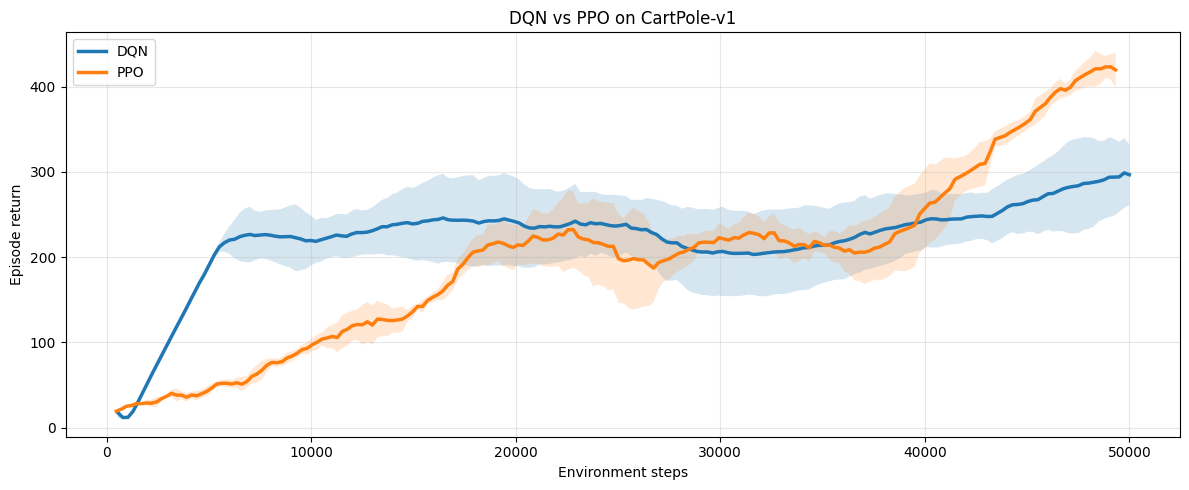

In [5]:
fig, ax = plot_comparison(
    results,
    window=WINDOW,
    title="DQN vs PPO on CartPole-v1",
    ylabel="Episode return",
)

In [6]:
main_summary = print_score_table(results, window=WINDOW)
main_summary

DQN: 296.77 +/- 35.71
PPO: 419.72 +/- 20.00


,algorithm,mean_final_return,std_final_return,per_seed
0,DQN,296.766673,35.713442,"[285.95001220703125, 259.45001220703125, 344.8..."
1,PPO,419.716675,20.001511,"[391.70001220703125, 437.1000061035156, 430.35..."


### Individual Algorithm Ablations

Each ablation keeps the environment fixed and changes one implementation or hyperparameter group at a time. These cells use one seed and a smaller step budget by default so they are practical to iterate on; set `ABLATION_SEEDS = SEEDS` and increase `ABLATION_ENV_STEPS` for report-quality runs.

DQN ablations:
- `hard_target_100`: target network is copied every 100 learned updates instead of soft-updated every update.
- `fast_eps_decay`: exploration epsilon decays faster.
- `small_replay`: replay capacity is reduced.

PPO ablations:
- `clip_0.10` and `clip_0.30`: smaller or larger PPO clipping ranges.
- `no_entropy_bonus`: removes the entropy bonus.

In [7]:
ABLATION_SEEDS = [0]
ABLATION_ENV_STEPS = 10_000

100%|██████████| 10000/10000 [00:04<00:00, 2254.28it/s]

baseline: 257.90 +/- 0.00
hard_target_100: 373.00 +/- 0.00
fast_eps_decay: 318.95 +/- 0.00
small_replay: 257.90 +/- 0.00


,algorithm,mean_final_return,std_final_return,per_seed
0,baseline,257.899994,0.0,[257.8999938964844]
1,hard_target_100,373.000000,0.0,[373.0]
2,fast_eps_decay,318.950012,0.0,[318.95001220703125]
3,small_replay,257.899994,0.0,[257.8999938964844]


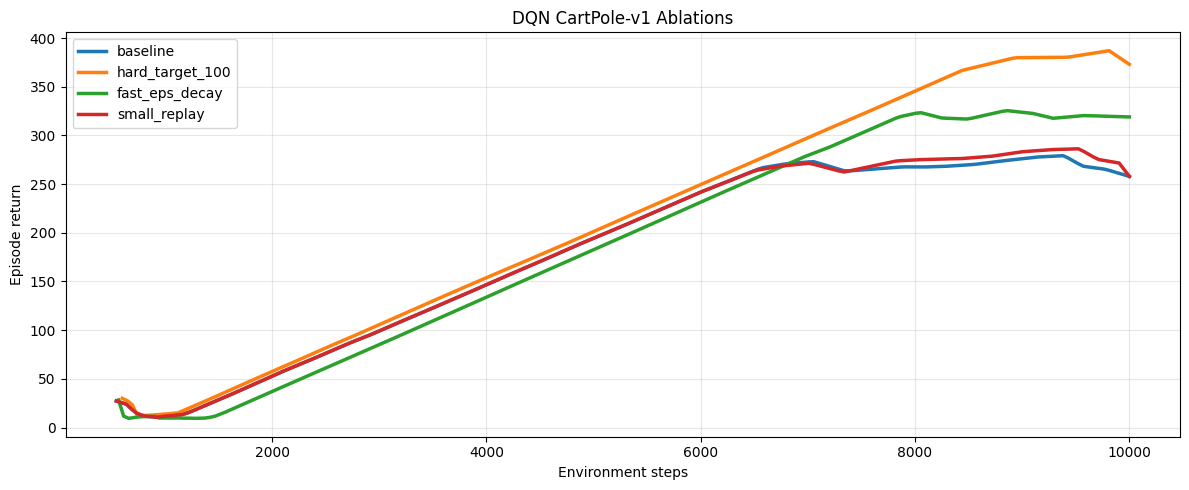

In [8]:
dqn_ablations = run_dqn_cartpole_ablations(
    seeds=ABLATION_SEEDS,
    total_env_steps=ABLATION_ENV_STEPS,
    progress=True,
)

fig, ax = plot_comparison(
    dqn_ablations,
    window=WINDOW,
    title="DQN CartPole-v1 Ablations",
    ylabel="Episode return",
)

dqn_ablation_summary = print_score_table(dqn_ablations, window=WINDOW)
dqn_ablation_summary

100%|██████████| 19/19 [00:01<00:00, 18.34it/s]

baseline: 83.50 +/- 0.00
clip_0.10: 77.85 +/- 0.00
clip_0.30: 75.70 +/- 0.00
no_entropy_bonus: 92.95 +/- 0.00


,algorithm,mean_final_return,std_final_return,per_seed
0,baseline,83.500000,0.0,[83.5]
1,clip_0.10,77.849998,0.0,[77.8499984741211]
2,clip_0.30,75.699997,0.0,[75.69999694824219]
3,no_entropy_bonus,92.949997,0.0,[92.94999694824219]


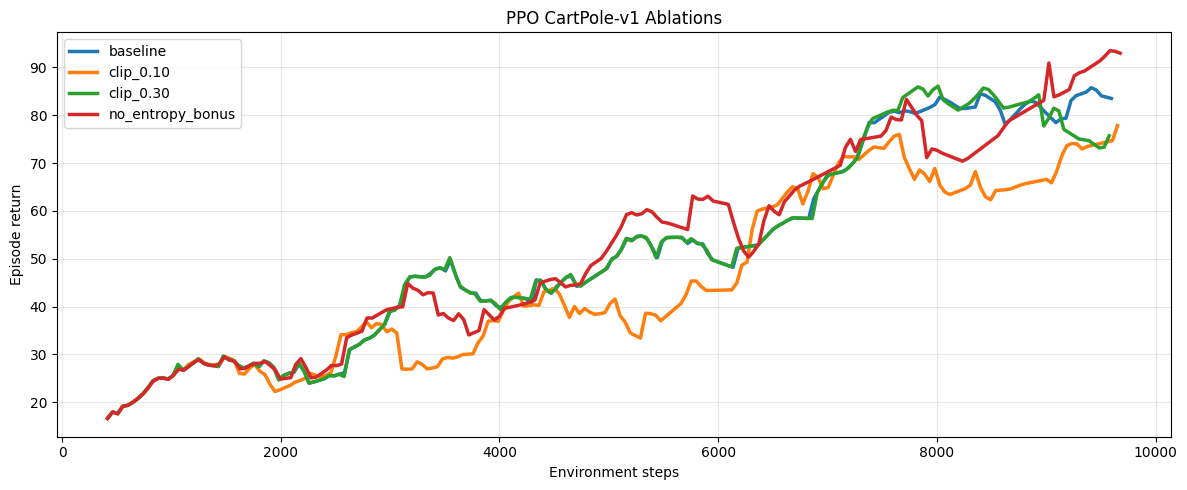

In [9]:
ppo_ablations = run_ppo_cartpole_ablations(
    seeds=ABLATION_SEEDS,
    total_env_steps=ABLATION_ENV_STEPS,
    progress=True,
)

fig, ax = plot_comparison(
    ppo_ablations,
    window=WINDOW,
    title="PPO CartPole-v1 Ablations",
    ylabel="Episode return",
)

ppo_ablation_summary = print_score_table(ppo_ablations, window=WINDOW)
ppo_ablation_summary